# 01 · Set up a project and explore the data

**Use case.** A data team gets three CSV exports from a bookstore's review system — `customer`, `product`, `review` — and wants them queryable, joined and charted in minutes, with no ETL and no notebook full of `pd.merge`. This is the notebook every other one builds on.

**What you will learn**
1. Sign in with an API key and see who the key acts as
2. Create a project and upload the three CSVs — the API counts rows and enforces your plan's row cap
3. Let Langsat detect primary keys, foreign keys and the time column
4. See what a clean would cost, then clean (free under 500K rows)
5. Read rows into pandas — filters, sorting, search, paging
6. Build charts on a dashboard, draw them **as images** in the notebook, publish a public link
7. Let the AI build a dashboard (`generate_cards`), and ask questions in plain English — with a chart you can plot from code

**What this costs.** no training. Cleaning is 0 credits under 500K rows; `generate_cards` and each `ask` count against your AI quota (not credits).

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

## 1 · Sign in

`Langsat()` reads the key that `langsat login` saved (or `LANGSAT_API_KEY`). A key *is* you: your plan's limits, your credits, your team role — the API refuses anything the key's scopes don't cover, with a typed error.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, print_schema, train_or_reuse, credits_used, save_metrics, show, fig, metrics_table, project_models
from langsat import viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'TEST-SDK-4' with 20 scopes


In [2]:
me = ls.me()
print(f"{me['email']} · plan {me['tier']} · teams: {[t['name'] for t in me.get('teams', [])]}")
print("this key may:", ", ".join(me["api_key"]["scopes"]))

team@langsat.ai · plan team · teams: ['Internal Comp Team']
this key may: chat, credits:read, dashboards:read, dashboards:write, data:read, data:write, hosting:write, inference:read, keys:read, model:read, monitoring:read, monitoring:write, predict, projects:read, projects:write, sources:write, teams:read, train, webhooks:read, webhooks:write


## 2–4 · Project, upload, schema, clean

`get_or_create_project` (in `_common.py`) is thirty lines you could inline: find the project by name or create it, `sources.upload(*paths)` (presign → S3 → confirm), `schema.detect().wait()`, `cleaning.clean().wait()` — skipping any step the project already did. Watch the log: it says which steps ran.

In [3]:
p = get_or_create_project(ls, "explore", kind="data_analysis")
sr = print_schema(p)

reusing project 0b6ffd93-08da-4220-9dfa-5b62b5f5951f (amazon-reviews-explore, status=schema_done)


project ready: status=schema_done · type=data_analysis · files=['customer.csv', 'product.csv', 'review.csv']


primary keys : {'review': '__row_id__', 'product': 'product_id', 'customer': 'customer_id'}
foreign keys : {'review': {'product_id': 'product', 'customer_id': 'customer'}, 'product': {}, 'customer': {}}
time columns : {'review': 'review_time', 'product': None, 'customer': None}


  customer: 9821 rows · 2 columns
  product: 8607 rows · 6 columns
  review: 10000 rows · 7 columns


Langsat found the relationships itself: `review.customer_id → customer`, `review.product_id → product`, and `review_time` as the time column — nothing was declared. `review` got a synthetic primary key (`__row_id__`) because a review has no natural id.

`estimates()` says what each paid action would cost *before* you run it. For this project cleaning is free (under 500K rows), and an AI question costs one unit of your daily quota.

In [4]:
est = p.estimates()
print("clean :", est["clean"])
print("ask   :", est["ask"])
print("predict:", est["predict"])

clean : {'credits': 0, 'lane': 'lambda'}
ask   : {'ai_questions': 1, 'quota': {'available': True, 'pct_today': 0, 'pct_month': 0, 'reason': None}}
predict: {'credits_per_call': 50}


## 5 · Rows into pandas

`table(name)` reads the *cleaned* data (types normalised — `verified` became 0/1). `rows()` is one page (≤200), `iter_rows()` walks pages, `to_pandas()` collects up to 100K rows. Filters are `(column, op, value)` triples the server applies — the same operators the app's filter bar uses.

In [5]:
review = p.table("review").to_pandas()
product = p.table("product").to_pandas()
customer = p.table("customer").to_pandas()
print(review.shape, product.shape, customer.shape)
review.head(3)

(10000, 7) (8607, 6) (9821, 2)


,review_time,customer_id,product_id,rating,verified,review_text,summary
0,2015-02-06T00:00:00,1474411,246851,5,1,"Loved Loved Loved it!! I laughed, I cried, it...",Another great one!!
1,2014-07-04T00:00:00,2352,247002,5,1,A wave of sadness came over her but she saw th...,An engrossing and satisfying read
2,2018-01-24T00:00:00,245552,246966,5,1,Totally loved this second book in the series! ...,Fabulous


In [6]:
# server-side filter + sort + search: 5-star reviews that mention "kids", newest first
page = p.table("review").rows(filters=[("rating", "eq", 5)], search="kids", sort=[("review_time", "desc")], page_size=5)
print(page.total, "matching reviews; first page:")
page.to_pandas()[["review_time", "rating", "summary"]]

133 matching reviews; first page:


,review_time,rating,summary
0,2018-04-26T00:00:00,5,"Love, love this book"
1,2018-02-18T00:00:00,5,Five Stars
2,2018-02-04T00:00:00,5,Great Gift for Nieces and Nephews
3,2018-01-04T00:00:00,5,Five Stars
4,2017-12-08T00:00:00,5,Five Stars


In [7]:
print("rating distribution:"); print(review["rating"].value_counts().sort_index().to_dict())
print(f"verified purchases: {review['verified'].astype(int).mean():.1%}")
print(f"reviews per customer: max {review.customer_id.value_counts().max()} · products with ≥5 reviews: {(review.product_id.value_counts() >= 5).sum()}")

rating distribution:
{1: 282, 2: 358, 3: 850, 4: 2199, 5: 6311}
verified purchases: 71.2%
reviews per customer: max 4 · products with ≥5 reviews: 58


A first look at time. `review_time` spans 2008 → September 2018; the count per year and the mean rating side by side.

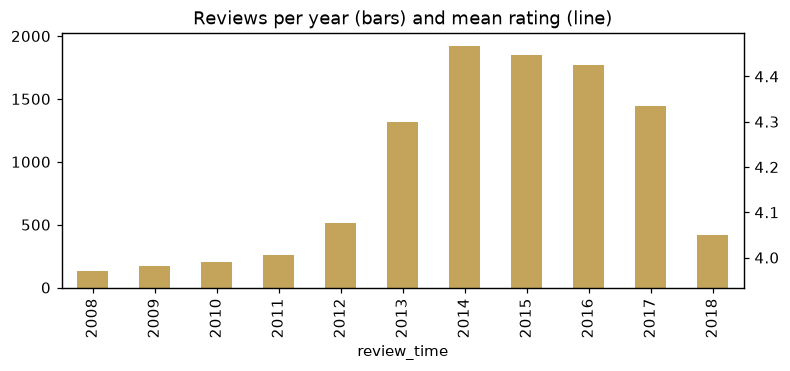

In [8]:
import matplotlib.pyplot as plt
review["review_time"] = pd.to_datetime(review["review_time"])
by_year = review.groupby(review["review_time"].dt.year)["rating"].agg(["count", "mean"])
f, ax = plt.subplots(figsize=(8, 3))
by_year["count"].plot(kind="bar", ax=ax, color="#c4a35a", title="Reviews per year (bars) and mean rating (line)")
by_year["mean"].plot(ax=ax.twinx(), color="#c0392b", marker="o"); fig(f)

## 6 · A dashboard, drawn as images

A **recipe chart** is deterministic — tables, a grouping, a measure, optional joins and a Top N — no AI, no credits, and the server re-aggregates it on every data refresh. When a grouping has thousands of values (6,000+ brands here) the API refuses an unreadable axis and tells you to add a Top N.

`langsat.viz` turns any chart the platform produces into a matplotlib figure — the same Plotly JSON the app renders, drawn as a PNG so it shows in GitHub, in a PDF, in an email.

In [9]:
tab = next((t for t in p.dashboards.list() if t.name == "Reviews"), None) or p.dashboards.create("Reviews")
tab.refresh()
have = {c.title for c in tab.charts}
if "Reviews by rating" not in have:
    tab.add_chart({"tables": ["review"], "chart_type": "bar", "group_by": [{"column": "rating"}],
                   "measure": {"agg": "count", "column": "rating"}}, title="Reviews by rating")
if "Most-reviewed brands (joined, top 10)" not in have:
    tab.add_chart({"tables": ["review", "product"], "chart_type": "bar", "group_by": [{"column": "brand"}],
                   "measure": {"agg": "count", "column": "rating"},
                   "joins": [{"table": "product", "left_column": "product_id", "right_column": "product_id"}],
                   "order_by": {"dir": "desc", "limit": 10}},                         # 6,000+ brands → Top 10
                  title="Most-reviewed brands (joined, top 10)")
if "Mean rating by year" not in have:
    tab.add_chart({"tables": ["review"], "chart_type": "scatter", "mode": "lines",
                   "group_by": [{"column": "review_time", "transform": "to_year"}],
                   "measure": {"agg": "avg", "column": "rating"}}, title="Mean rating by year")
tab.refresh()
for c in tab.charts:
    print(c.id, "·", c.title, "·", (c.recipe or {}).get("chart_type"))

w-39637bbb · Reviews by rating · bar
w-d67e2291 · Most-reviewed brands (joined, top 10) · bar
w-02c1dc96 · Mean rating by year · scatter
w-8879f5e2 · Number of reviews per rating (from chat) · bar


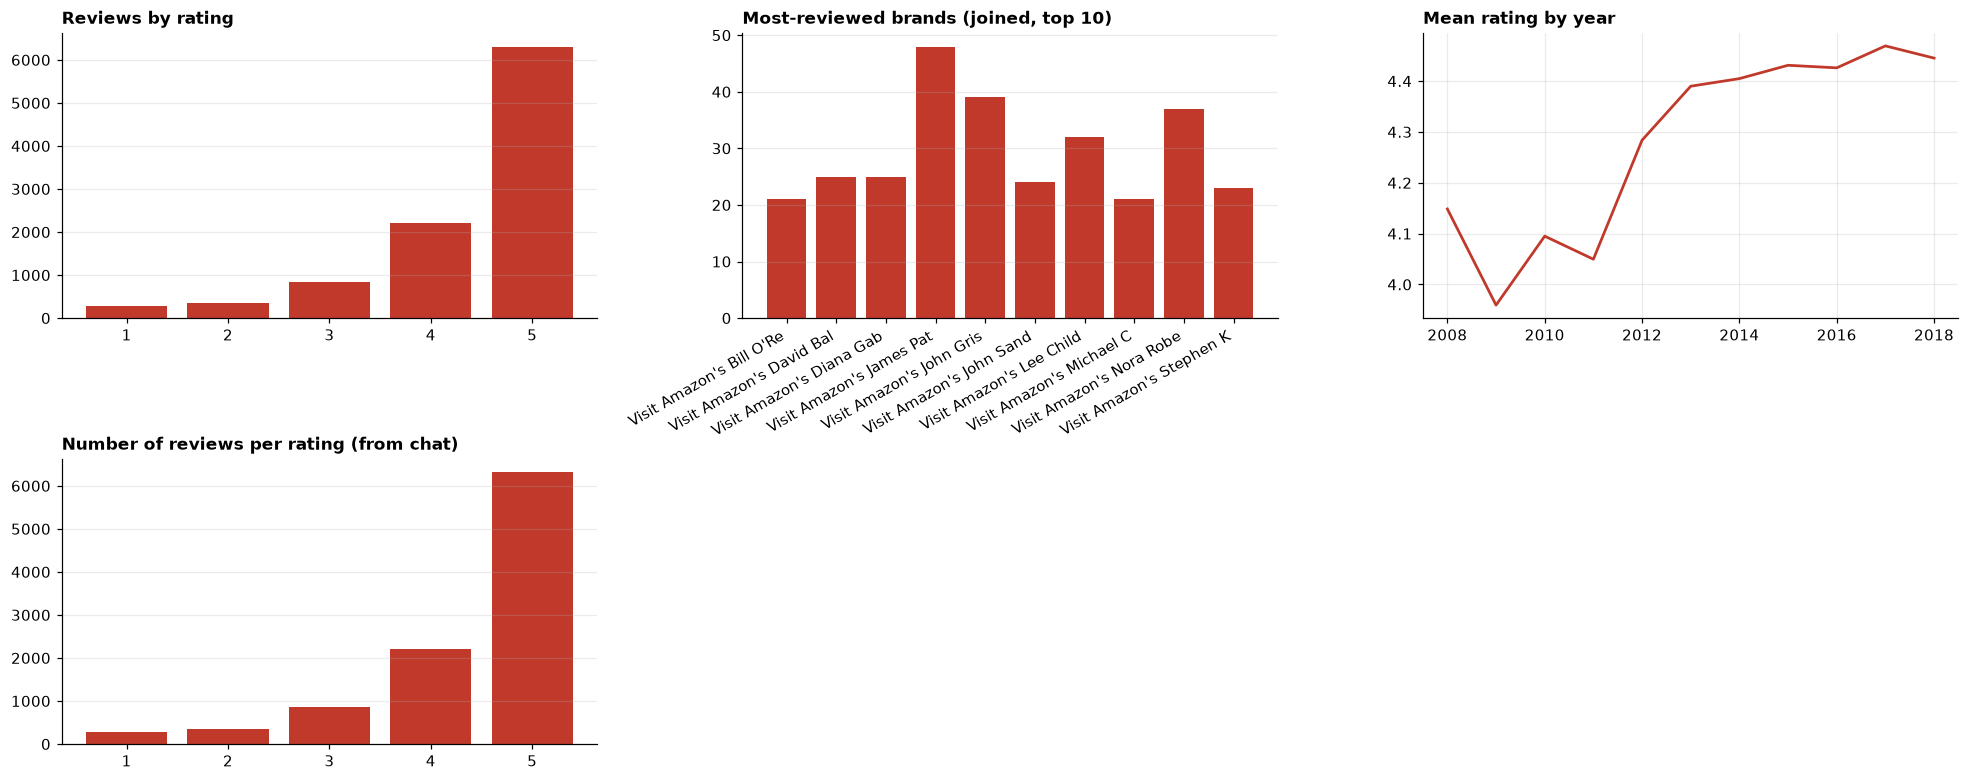

In [10]:
fig(viz.draw_tab(tab, cols=3))                     # every widget of the tab, re-aggregated by the server

Behind each chart is the data the dashboard shows — `chart.data(op="page")` gives the rows, `op="aggregate"` the Plotly render. Useful when you want the numbers, not the picture.

In [11]:
chart = tab.chart("Most-reviewed brands (joined, top 10)")
pd.DataFrame(chart.data(op="page", page_size=10)["rows"])[["x", "y"]].rename(columns={"x": "brand", "y": "reviews"})

,brand,reviews
0,Visit Amazon's James Patterson Page,48
1,Visit Amazon's John Grisham Page,39
2,Visit Amazon's Nora Roberts Page,37
3,Visit Amazon's Lee Child Page,32
4,Visit Amazon's David Baldacci Page,25
5,Visit Amazon's Diana Gabaldon Page,25
6,Visit Amazon's John Sandford Page,24
7,Visit Amazon's Stephen King Page,23
8,Visit Amazon's Bill O'Reilly Page,21
9,Visit Amazon's Michael Connelly Page,21


### Publish a link

A **published** share is a frozen copy of the tab whose numbers still follow data refreshes. The token is returned **once**, at creation; the page it opens is also what an `<iframe>` embeds. Below: the tab's existing published share is revoked and a fresh one minted (so the notebook can show the link), then the same widgets are re-read from the public JSON — no key needed — to prove the share is self-contained.

In [12]:
for s in tab.shares():
    if s.get("mode") == "published":
        tab.revoke_share(s["share_id"])                # the old link stops working; the new one below replaces it
link = tab.share(mode="published")
token = link["token"]
print("public page :", tab.embed_url(token))
import httpx
public = httpx.get(f"{ls.base_url}/public/share/{token}", timeout=30).json()
print("public JSON :", public.get("tab_name"), "·", len(public.get("widgets", [])), "widgets · published", str((public.get("published") or {}).get("published_at"))[:19])
print("widgets     :", [w.get("title") for w in public.get("widgets", [])])

public page : https://langsat.ai/embed/4zIGylXmyPIM86FVI7I0LDJq_ZqExp0soWCLDV4IPWLrQsCTAijAeriM3UNYNklE


public JSON : Reviews · 4 widgets · published 2026-09-16T02:13:42
widgets     : ['Reviews by rating', 'Most-reviewed brands (joined, top 10)', 'Mean rating by year', 'Number of reviews per rating (from chat)']


### Let the AI build a dashboard

`generate_cards()` is the app's **Add Dashcard** button: it fills a tab with a data preview and five charts about the next table nobody has explored yet (customer, then product, then review), renames the tab after that table, and — once every table has a tab — switches to cross-table charts. One dashboard-generation unit of your quota per call. The cards are recipe charts too: you can read their recipes, they refresh with the data, and `viz.draw_tab` draws them like any other tab.

tab 'customer': 6 cards → ['customer — Data Preview', 'Top 15 customers by number of reviews', 'Average rating given by most-active customers (top 15)'] …
tab 'product': 6 cards → ['product — Data Preview', 'Distribution of product prices', 'Products by top-level category (top 15)'] …
tab 'review': 6 cards → ['review — Data Preview', 'Distribution of review ratings', 'Verified vs unverified: average rating comparison'] …


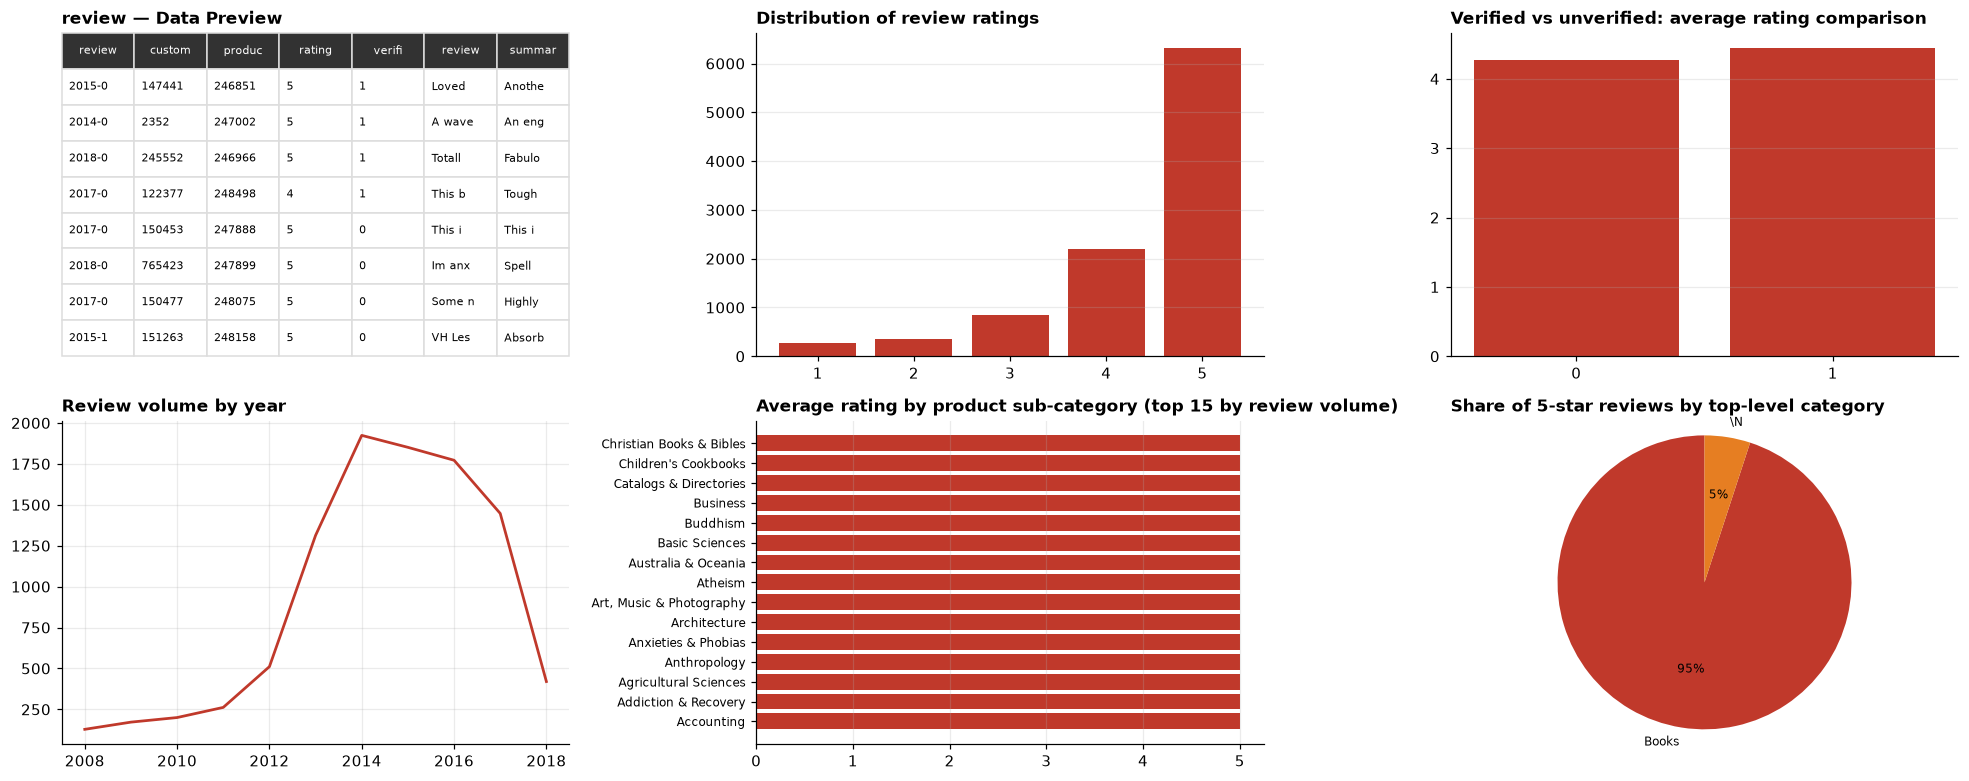

In [13]:
explored = [t for t in p.dashboards.list() if any(w.get("type") == "data_table" for w in t.refresh().widgets)]   # list() is a summary; refresh() loads the widgets
if not explored:
    ai = p.dashboards.create("AI cards").generate_cards().refresh()      # becomes the "customer" tab
    explored = [ai]
for t in explored:
    print(f"tab {t.name!r}: {len(t.charts)} cards →", [c.title for c in t.charts][:3], "…")
fig(viz.draw_tab(explored[-1], cols=3))

A table-preview card is drawn as a table; the recipe behind any card is on `chart.recipe` — the same JSON `add_chart` accepts, so an AI card can be copied to your own tab or edited.

In [14]:
card = next(c for c in explored[-1].charts if c.recipe)
json.dumps(card.recipe, indent=1)[:600]

'{\n "bins": null,\n "tables": [\n  "review"\n ],\n "measure": {\n  "agg": "count"\n },\n "version": 1,\n "group_by": [\n  {\n   "role": "x",\n   "column": "rating",\n   "transform": null\n  }\n ],\n "order_by": null,\n "chart_type": "bar",\n "base_filter": null,\n "render_layout": {\n  "xaxis": {\n   "title": "Star Rating"\n  },\n  "yaxis": {\n   "title": "Number of Reviews"\n  }\n }\n}'

## 7 · Ask the data — and plot the answer from code

`ask()` is the app's chat. The answer carries the text, how it was produced (`execution_kind`: SQL, code, or a model) and any **chart specs** — Plotly figures you can draw with `viz` or pin to a dashboard with `tab.add_chart_spec`. `force_chart=True` tells the model a chart is required.

In [15]:
a = p.ask("Which year had the lowest average rating, and how many reviews were written that year?", timeout=300)
print(a.text)
print("\nexecution:", a.execution_kind, "· charts:", len(a.charts))

## Year with Lowest Average Rating

**Year**: 2009
**Average rating**: 3.9593
**Number of reviews**: 172

### All Years (sorted by average rating)
| Year | Avg Rating | Review Count |
|------|------------|--------------|
| 2009 | 3.9593 | 172 |
| 2011 | 4.0496 | 262 |
| 2010 | 4.0950 | 200 |
| 2008 | 4.1484 | 128 |
| 2012 | 4.2838 | 511 |
| 2013 | 4.3899 | 1313 |
| 2014 | 4.4049 | 1924 |
| 2016 | 4.4261 | 1772 |
| 2015 | 4.4311 | 1851 |
| 2018 | 4.4452 | 420 |
| 2017 | 4.4692 | 1447 |

execution: code · charts: 0


(the answer is the chart itself)
execution: code · chart specs: ['Number of Reviews per Rating'] · plots: 0


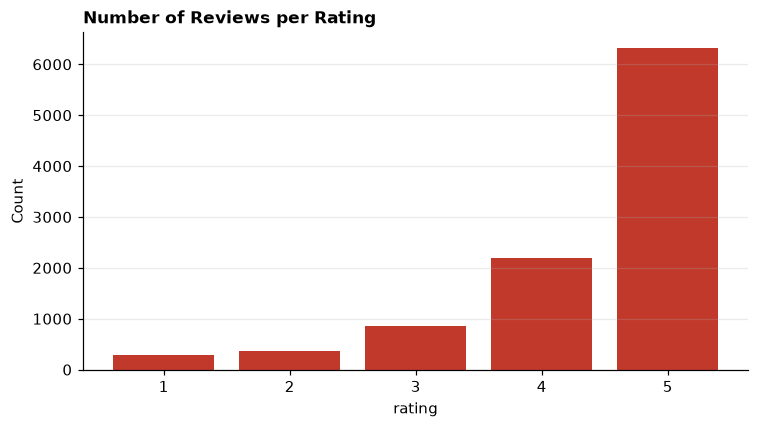

In [16]:
b = p.ask("Show the number of reviews per rating as a bar chart", force_chart=True, timeout=300)
print(b.text[:300] or "(the answer is the chart itself)")
print("execution:", b.execution_kind, "· chart specs:", [c.get("title") for c in b.charts], "· plots:", len(b.plots))
for f in b.figures():
    fig(f)

Pin it. The chart becomes a widget on the tab, exactly as the app's *Add to dashboard* does — and a follow-up question can reference the conversation.

In [17]:
if b.charts and "Number of reviews per rating (from chat)" not in {c.title for c in tab.charts}:
    tab.add_chart_spec(b.charts[0], title="Number of reviews per rating (from chat)")
print([c.title for c in tab.charts])
c2 = p.ask("And what share of those are verified purchases, per rating?", conversation_id=b.conversation_id, timeout=300)
print(c2.text[:400])

['Reviews by rating', 'Most-reviewed brands (joined, top 10)', 'Mean rating by year', 'Number of reviews per rating (from chat)']


## Verified Purchase Share by Rating
| Rating | Verified % |
|--------|-----------|
| 1 | 61.3% |
| 2 | 70.7% |
| 3 | 64.8% |
| 4 | 65.3% |
| 5 | 74.6% |


In [18]:
save_metrics(".", {"notebook": "01_setup_and_explore", "task": "setup + explore (no model)", "model": "—",
                   "project_id": p.id, "tables": {t["name"]: t["rows"] for t in p.tables.list()},
                   "foreign_keys": sr["schema_data"]["foreign_keys"], "charts": [c.title for c in tab.charts], "ai_tabs": [t.name for t in explored],
                   "headline": {"published_link": bool(token), "chat_chart": bool(b.charts), "answer_chars": len(a.text)}})

wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [02 · Rating regression](../02_rating_regression/) — the first model on this data
- [07 · Forecast](../07_forecast_review_volume/) — the same project, no training
- The SDK reference: `help(ls.projects)`, `help(p.table('review'))`, `help(langsat.viz)`